In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
hbar = 1
#hbar = 6.62607015*10**(-34)

In [6]:
def init_sq_th(alpha_: np.float64, theta_: np.float64, mean_n_: np.float64):
    th_vac_matrix_ = np.zeros((4,4), dtype=np.float64)
    np.fill_diagonal(th_vac_matrix_, mean_n_ + 1/2)

    sq_matrix_ = np.zeros((4,4), dtype=np.float64)
    np.fill_diagonal(sq_matrix_, np.cosh(alpha_))
    sq_matrix_[0][2], sq_matrix_[2][0] = np.sinh(alpha_)*np.cos(theta_), np.sinh(alpha_)*np.cos(theta_)
    sq_matrix_[0][3], sq_matrix_[3][0] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix_[1][2], sq_matrix_[2][1] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix_[1][3], sq_matrix_[3][1] = -np.sinh(alpha_)*np.cos(theta_), -np.sinh(alpha_)*np.cos(theta_)
    return sq_matrix_ @ th_vac_matrix_ @ sq_matrix_.T

def create_bipartite_states(type_: str, amount_of_states_: np.float64):
    if type_ == "sq_th":
        theta_sq_th_ = np.random.uniform(0,2*np.pi,(amount_of_states_,))
        s_sq_th_ = np.random.uniform(0.8,0.95,(amount_of_states_,))
        phi_sq_th_ = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (amount_of_states_,))
        abs_alpha_sq_th_ = np.array([x*np.sin(y) for x, y in zip(s_sq_th_,phi_sq_th_)])
        mean_n_sq_th_ = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s_sq_th_,phi_sq_th_)])

        #Initialize covariance matrices for input states
        return np.array([init_sq_th(x,y,z) for x,y,z in zip(abs_alpha_sq_th_,theta_sq_th_,mean_n_sq_th_)])
    else:
        print(f"{type_} not possible")

#Changes the input state interacting with the reservoir
def inject_input(cov_M_: np.array, input_state_: np.array):
    cov_M_[:4,4:] = 0
    cov_M_[4:,:4] = 0
    cov_M_[:4,:4] = input_state_

#Initializes the covariance matrix
def init_cov_full():
    cov_full_ = np.zeros((12,12), dtype=np.float64)
    np.fill_diagonal(cov_full_[4:,4:], 1/2)
    return cov_full_

#Initializes the matrix A which contains the information of the Langevian equations
def init_A(gamma_: np.float64, P_: np.float64, W_in_: np.array, J_ij_: np.array, eta_: np.float64):
    A_ = np.zeros((12,12), dtype=np.float64)
    #First 1-4x1-4 submatrix
    A_[0][0], A_[1][1], A_[2][2], A_[3][3] =  -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_)
    #5-12x1-4 submatrix
    A_[4][0], A_[6][0], A_[8][0], A_[10][0] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[5][1], A_[7][1], A_[9][1], A_[11][1] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[4][2], A_[6][2],A_[8][2], A_[10][2] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A_[5][3], A_[7][3], A_[9][3], A_[11][3] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    #5-12x5-12 submatrix diagonal
    A_[4][4], A_[6][6], A_[8][8], A_[10][10] = -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2
    A_[5][5], A_[7][7], A_[9][9], A_[11][11] = -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2
    #5-12x5-12 submatrix other values row by row
    A_[4][7], A_[4][9], A_[4][11], A_[5][6], A_[5][8], A_[5][10] = J_ij_[0], J_ij_[1], J_ij_[2], -J_ij_[0], -J_ij_[1], -J_ij_[2]
    A_[6][5], A_[6][9], A_[6][11], A_[7][4], A_[7][8], A_[7][10] = J_ij_[0], J_ij_[3], J_ij_[4], -J_ij_[0], -J_ij_[3], -J_ij_[4]
    A_[8][5], A_[8][7], A_[8][11], A_[9][4], A_[9][6], A_[9][10] = J_ij_[1], J_ij_[3], J_ij_[5], -J_ij_[1], -J_ij_[3], -J_ij_[5]
    A_[10][5],  A_[10][7], A_[10][9], A_[11][4], A_[11][6], A_[11][8] = J_ij_[2], J_ij_[4], J_ij_[5], -J_ij_[2], -J_ij_[4], -J_ij_[5]

    A_ = (1/hbar)*A_
    
    #Initialize first mode interaction matrix
    first_mode_ = copy.copy(A_)
    first_mode_[:,[2,3]] = 0
    #Initialize second mode interaction matrix
    second_mode_ = copy.copy(A_)
    second_mode_[:,[0,1]] = 0
    #Initialize A mode with only reservoir interaction
    nointeract_mode_ = copy.copy(A_)
    nointeract_mode_[:,[0,1,2,3]] = 0

    #Return the different interaction modes
    return (first_mode_, second_mode_, nointeract_mode_, A_)

def init_D(gamma_: np.float64, P_: np.float64, eta_: np.float64):
    D_ = np.zeros((12,12), dtype=np.float64)
    np.fill_diagonal(D_[:4,:4], eta_/(2*gamma_))
    np.fill_diagonal(D_[4:,4:], (gamma_-P_)/2)

    first_mode_ = copy.copy(D_)
    first_mode_[:,[2,3]] = 0
    #Initialize second mode interaction matrix
    second_mode_ = copy.copy(D_)
    second_mode_[:,[0,1]] = 0
    #Initialize A mode with only reservoir interaction
    nointeract_mode_ = copy.copy(D_)
    nointeract_mode_[:,[0,1,2,3]] = 0

    return (first_mode_, second_mode_, nointeract_mode_, D_)

#Evolves system for one input pair
def time_evolve(cov_M_: np.array, first_mode_A_: np.array, second_mode_A_:np.array, nointeract_mode_A_: np.array,
                first_mode_D_: np.array, second_mode_D_:np.array, nointeract_mode_D_: np.array, time_steps_: np.float64, tau_: np.float64):

    def piecewice(t_, _cov_M_):
        t_ = np.round(t_, 6)
        if 0 < t_ < tau_:
            return first_mode_A_ @ _cov_M_ + _cov_M_ @ first_mode_A_.T + first_mode_D_
        elif tau_ < t_ < 2*tau_:
            return second_mode_A_ @ _cov_M_ + _cov_M_ @ second_mode_A_.T + second_mode_D_
        else:
            return nointeract_mode_A_ @ _cov_M_ + _cov_M_ @ nointeract_mode_A_.T + nointeract_mode_D_
    
    step_size_ = np.round(2*tau_/time_steps_,6)

    def rk4(function_, t_, _cov_M_, step_):
        k1_ = function_(t_, _cov_M_)
        k2_ = function_(t_ + 0.5 * step_, _cov_M_ + 0.5 * step_ * k1_)
        k3_ = function_(t_ + 0.5 * step_, _cov_M_ + 0.5 * step_ * k2_)
        k4_ = function_(t_ + step_, _cov_M_ + step_ * k3_)
        return cov_M_ + (step_/6)*(k1_ + 2 * k2_ + 2 * k3_ + k4_)

    for current_time in np.arange(0, 2*tau_, step_size_):
        cov_M_ = rk4(piecewice, current_time, cov_M_, step_size_)
        
    #Return the time-evolved covariance matrix
    return cov_M_

#Calculates the occupation numbers of reservoir sites
def get_occupation_nums(cov_M_: np.array, reservoir_size_: np.float64):
    return np.array([(1/2)*(cov_M_[4+2*i][4+2*i] + cov_M_[5+2*i][5+2*i] - 1) for i in range(reservoir_size_)])

#Predicts Y_out
def predict_Y_out(occupation_numbers_: np.array, W_out_: np.array):
    return sum([x*y for x, y in zip(W_out_[0], occupation_numbers_)]), sum([x*y for x, y in zip(W_out_[1], occupation_numbers_)])

#Predicts entanglement of input
def predict_Y_out_entanglement(occupation_numbers_: np.array, W_out_: np.array):
    pred_ = sum([x*y for x, y in zip(W_out_[0], occupation_numbers_)]), sum([x*y for x, y in zip(W_out_[1], occupation_numbers_)])

    if pred_[0] > pred_[1]:
        return (1,0)
    return (0,1)

#Updates the output weights of network
def update_W_out(learning_rate_: np.float64, reg_strength_: np.float64, Y_true_: tuple, Y_pred_: tuple, occupation_numbers_: np.array, W_out_: np.array, reservoir_size_: np.float64):

    for i in range(reservoir_size_):
        W_out_[i][0] = W_out_[i][0] + learning_rate_*(occupation_numbers_[i]*(Y_true_[0]-Y_pred_[0]) - reg_strength_*W_out_[i][0])
        W_out_[i][1] = W_out_[i][1] + learning_rate_*(occupation_numbers_[i]*(Y_true_[1]-Y_pred_[1]) - reg_strength_*W_out_[i][1])
    
#Calculates negativity of input state
def negativity(input_state_: np.array):
    det_V_ = np.linalg.det(input_state_)
    det_A_ = np.linalg.det(input_state_[:2,:2])  
    det_B_ = np.linalg.det(input_state_[2:,2:])
    det_C_ = np.linalg.det(input_state_[:2,2:])
    sigma_ = det_A_ + det_B_ - 2*det_C_
    return -np.log(np.sqrt(2)*(np.sqrt(sigma_ - np.sqrt(sigma_**2 - 4*det_V_))))

#Reveals true entanglement of input
def assign_entanglement(negativity_: np.float64):
    if negativity_ <= 0:
        return (0,1)
    return (1,0)
    
def get_entanglement_values(input_states_):
    return np.array([assign_entanglement(negativity(input_)) for input_ in input_states_])


In [15]:
#Initialize variables
reservoir_size = 4

number_of_train_inputs = 200
number_of_sq_th_inputs = 200

input_states_train = create_bipartite_states("sq_th", number_of_train_inputs)
input_states_test_sq_th = create_bipartite_states("sq_th", number_of_sq_th_inputs)

Y_out_true_train = get_entanglement_values(input_states_train)
Y_out_true_test_sq_th = get_entanglement_values(input_states_test_sq_th)

occupation_nums_train = []
occupation_nums_sq_th = []

Y_out_pred_train = np.empty(number_of_train_inputs, dtype=tuple)
Y_out_pred_sq_th = np.empty(number_of_sq_th_inputs, dtype=tuple)

gamma = 1
P = 0.1*gamma
tau = hbar/gamma

W_in = np.random.uniform(0, gamma, (4,))
J_ij = np.random.uniform(-gamma, gamma, (6,))
eta = np.sum(W_in**2)

learning_rate = 0.1
regularization_strength = 0.05

In [16]:
#Initialize covariance matrix of system
cov_full = init_cov_full()
first_mode_A, second_mode_A, nointeract_mode_A, matrix_A = init_A(gamma, P, W_in, J_ij, eta)
first_mode_D, second_mode_D, nointeract_mode_D, matrix_D = init_D(gamma, P, eta)

time_steps = 8

#Simulate the quantum reservoir for the injection of initial training states
for idx, input in enumerate(input_states_train):
    print(occupation_nums_train)
    inject_input(cov_full, input)
    cov_full = time_evolve(cov_full, first_mode_A, second_mode_A, nointeract_mode_A, first_mode_D, second_mode_D, nointeract_mode_D, time_steps, tau)
    occupation_nums_train.append(get_occupation_nums(cov_full, reservoir_size))
    print("")
    print(idx)
    print(np.round(cov_full.diagonal()[4:], 3))
    print(occupation_nums_train[idx])
    print(Y_out_true_train[idx])
    #print(np.round(cov_full,2))
    

[]

0
[0.812 0.749 0.649 0.865 0.641 0.591 1.131 0.737]
[0.2803055  0.25714749 0.11572326 0.4336886 ]
[1 0]
[array([0.2803055 , 0.25714749, 0.11572326, 0.4336886 ])]

1
[0.733 0.905 1.025 0.733 0.658 0.704 0.749 1.219]
[0.31902431 0.37908211 0.18098349 0.48402966]
[1 0]
[array([0.2803055 , 0.25714749, 0.11572326, 0.4336886 ]), array([0.31902431, 0.37908211, 0.18098349, 0.48402966])]

2
[0.893 0.762 0.787 1.003 0.709 0.696 1.217 0.772]
[0.32721685 0.39511189 0.2025004  0.49455759]
[1 0]
[array([0.2803055 , 0.25714749, 0.11572326, 0.4336886 ]), array([0.31902431, 0.37908211, 0.18098349, 0.48402966]), array([0.32721685, 0.39511189, 0.2025004 , 0.49455759])]

3
[0.707 0.904 0.989 0.763 0.703 0.688 0.807 1.116]
[0.30551031 0.37582753 0.19539172 0.46171352]
[1 0]
[array([0.2803055 , 0.25714749, 0.11572326, 0.4336886 ]), array([0.31902431, 0.37908211, 0.18098349, 0.48402966]), array([0.32721685, 0.39511189, 0.2025004 , 0.49455759]), array([0.30551031, 0.37582753, 0.19539172, 0.46171352])]

4


In [10]:
W_out = np.array([[0,0],[0,0],[0,0],[0,0]], dtype=np.float64)

for idx, occ_nums in enumerate(occupation_nums_train):
    Y_out_pred_train[idx] = predict_Y_out_entanglement(occ_nums, W_out)
    update_W_out(learning_rate, regularization_strength, Y_out_true_train[idx], Y_out_pred_train[idx], occ_nums, W_out, reservoir_size)
    print("")
    print(idx)
    print(occ_nums)
    print(np.round(W_out, 3))
    


0
[0.12639234 0.35459764 0.14478021 0.50695222]
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]

1
[0.12639234 0.35459764 0.14478021 0.50695222]
[[ 0.013 -0.013]
 [ 0.035 -0.035]
 [ 0.014 -0.014]
 [ 0.051 -0.051]]

2
[0.18340395 0.45855567 0.16708461 0.56227667]
[[ 0.013 -0.013]
 [ 0.035 -0.035]
 [ 0.014 -0.014]
 [ 0.05  -0.05 ]]

3
[0.18473853 0.45424895 0.16091151 0.53725239]
[[-0.006  0.006]
 [-0.01   0.01 ]
 [-0.002  0.002]
 [-0.004  0.004]]

4
[0.19398567 0.48353752 0.17411218 0.58528309]
[[ 0.013 -0.013]
 [ 0.038 -0.038]
 [ 0.016 -0.016]
 [ 0.055 -0.055]]

5
[0.19370422 0.47760532 0.17003865 0.56867584]
[[ 0.013 -0.013]
 [ 0.038 -0.038]
 [ 0.016 -0.016]
 [ 0.055 -0.055]]

6
[0.19254489 0.47608901 0.16982602 0.56873503]
[[ 0.013 -0.013]
 [ 0.038 -0.038]
 [ 0.016 -0.016]
 [ 0.054 -0.054]]

7
[0.21115665 0.52802767 0.19117687 0.64431102]
[[ 0.013 -0.013]
 [ 0.038 -0.038]
 [ 0.015 -0.015]
 [ 0.054 -0.054]]

8
[0.19279552 0.46821199 0.16378923 0.5435613 ]
[[ 0.013 -0.013]
 [ 0.037 -0.037]
 [ 0.

IndexError: index 200 is out of bounds for axis 0 with size 200

In [38]:
print(Y_out_true_train[0], Y_out_pred_train[0])
for true, pred in zip(Y_out_true_train, Y_out_pred_train):
    print(f"True: {true}, Pred: ({np.round(pred[0],2)},{np.round(pred[1],2)})")


[1 0] (0, 1)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [0 1], Pred: (0,1)
True: [1 0], Pred: (0,1)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [1 0], Pred: (1,0)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [0 1], Pred: (0,1)
True: [0 1], Pred: (0,1)
True: [0 1], Pred: (0,1)
True: [0 1], Pred: (0,1)
True: [0 1], Pred: (0,1)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [1 0], Pred: (1,0)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [1 0], Pred: (1,0)
True: [0 1], Pred: (1,0)
True: [1 0], Pred: (0,1)
True: [0 1],

In [39]:
laskuri = 0
for true, pred in zip(Y_out_true_train, Y_out_pred_train):
    if true[0] == pred[0]:
        laskuri += 1

print(laskuri)

91


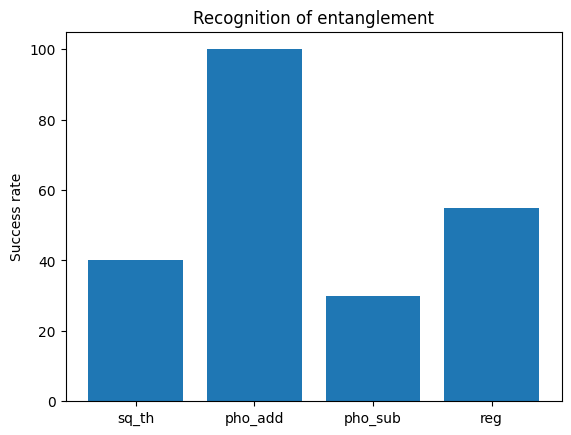

In [7]:
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [25]:
print(np.round(matrix_A,4))

[[-0.0889  0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.    ]
 [ 0.     -0.0889  0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.    ]
 [ 0.      0.     -0.0889  0.      0.      0.      0.      0.      0.
   0.      0.      0.    ]
 [ 0.      0.      0.     -0.0889  0.      0.      0.      0.      0.
   0.      0.      0.    ]
 [-0.0769  0.     -0.0769  0.     -0.045   0.      0.      0.0605  0.
   0.0263  0.     -0.0989]
 [ 0.     -0.0769  0.     -0.0769  0.     -0.045  -0.0605  0.     -0.0263
   0.      0.0989  0.    ]
 [-0.0296  0.     -0.0296  0.      0.      0.0605 -0.045   0.      0.
   0.0608  0.      0.0045]
 [ 0.     -0.0296  0.     -0.0296 -0.0605  0.      0.     -0.045  -0.0608
   0.     -0.0045  0.    ]
 [-0.0943  0.     -0.0943  0.      0.      0.0263  0.      0.0608 -0.045
   0.      0.     -0.0977]
 [ 0.     -0.0943  0.     -0.0943 -0.0263  0.     -0.0608  0.      0.
  -0.045   0.0977  0.    ]
 [-0.0456  0.     -